In [21]:
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_common import dlc, plot_data
from plt_one_addpt_onclick import plt_one_addpt_onclick
from lab_utils_common import plot_data, sigmoid, draw_vthresh
from plt_logistic_loss import  plt_logistic_cost, plt_two_logistic_loss_curves, plt_simple_example
from plt_logistic_loss import soup_bowl, plt_logistic_squared_error
plt.style.use('./deeplearning.mplstyle')

In [17]:
def sigmoid(z):
    z_safe = np.clip(z, -500, 500)
    g = 1 / (1 + np.exp(-z_safe))
    return g

In [12]:
# Generate an array of evenly spaced values between -10 and 10
z_tmp = np.arange(-10,11)

# Use the function implemented above to get the sigmoid values
y = sigmoid(z_tmp)

# Code for pretty printing the two arrays next to each other
np.set_printoptions(precision=3) 
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


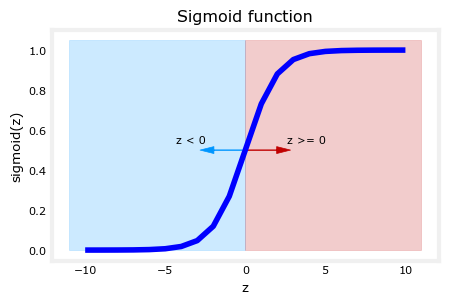

In [15]:
# Plot z vs sigmoid(z)
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')
draw_vthresh(ax,0)

In [18]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1) 

In [19]:
y

array([[0],
       [0],
       [0],
       [1],
       [1],
       [1]])

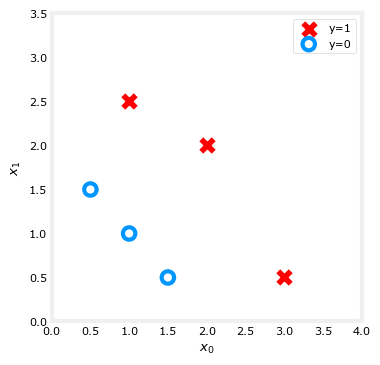

In [20]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X, y, ax)

ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_0$')
plt.show()

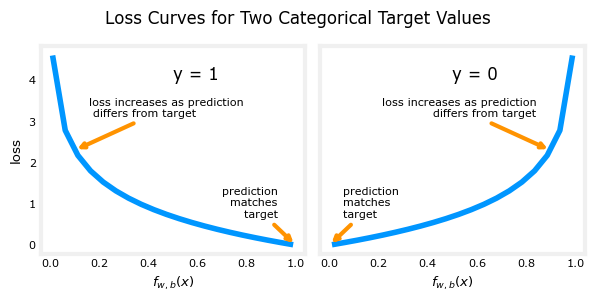

In [22]:
plt_two_logistic_loss_curves()

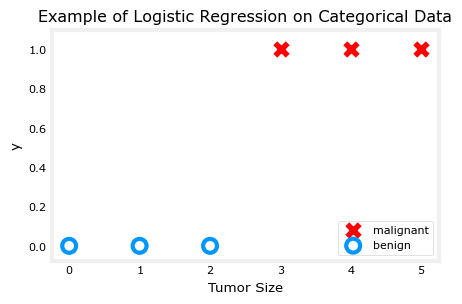

In [24]:
x_train = np.array([0., 1, 2, 3, 4, 5],dtype=np.longdouble)
y_train = np.array([0,  0, 0, 1, 1, 1],dtype=np.longdouble)
plt_simple_example(x_train, y_train)

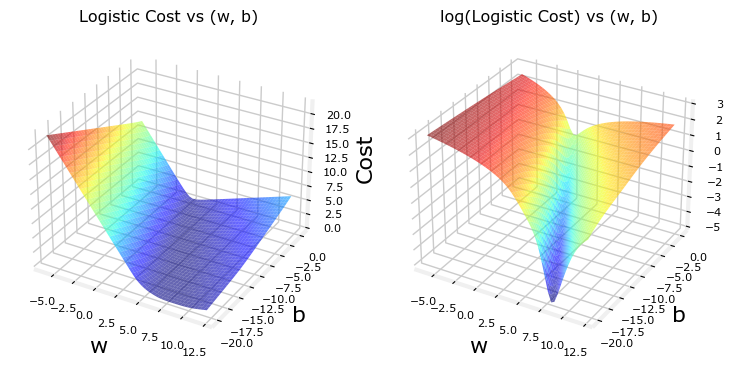

In [25]:
plt.close('all')
cst = plt_logistic_cost(x_train,y_train)

In [27]:
def compute_cost_logistic(x, y, w, b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(x[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)
    cost /= m
    return cost

In [30]:
def compute_gradient_logistic(x, y, w, b):
    m, n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m): # loop through sampels
        f_wb_i = sigmoid(np.dot(x[i], w) + b)
        err_i = f_wb_i - y[i]
        for j in range(n): # loop through features
            dj_dw[j] = dj_dw[j] + err_i * x[i, j]
        dj_db += err_i
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

In [31]:
import numpy as np

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Loss function (Binary Cross-Entropy)
def compute_loss(y_true, y_pred):
    m = len(y_true)  # Number of samples
    # Binary cross-entropy loss
    loss = -1/m * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# Gradient of the loss function
def compute_gradients(X, y_true, y_pred):
    m = len(y_true)  # Number of samples
    dw = 1/m * np.dot(X.T, (y_pred - y_true))  # Gradient for weights
    db = 1/m * np.sum(y_pred - y_true)          # Gradient for bias
    return dw, db

# Training function (Gradient Descent)
def train_logistic_regression(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape  # m = number of samples, n = number of features
    w = np.zeros(n)  # Initialize weights
    b = 0            # Initialize bias

    # Gradient Descent
    for epoch in range(epochs):
        # Calculate the linear model's output
        z = np.dot(X, w) + b
        # Apply sigmoid function to get predictions
        y_pred = sigmoid(z)
        
        # Compute the loss
        loss = compute_loss(y, y_pred)
        
        # Compute gradients
        dw, db = compute_gradients(X, y, y_pred)
        
        # Update weights and bias
        w -= learning_rate * dw
        b -= learning_rate * db
        
        # Print loss every 100 epochs (optional)
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss:.4f}')
    
    return w, b

# Example usage
# Generating some random data for binary classification (e.g., two classes)
np.random.seed(42)
X = np.random.randn(100, 2)  # 100 samples, 2 features
y = (np.dot(X, np.array([1, 2])) + 1 > 0).astype(int)  # Random labels based on a linear model

# Train the logistic regression model
w, b = train_logistic_regression(X, y, learning_rate=0.1, epochs=1000)

print("Trained weights:", w)
print("Trained bias:", b)

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.2947
Epoch 200, Loss: 0.2296
Epoch 300, Loss: 0.1987
Epoch 400, Loss: 0.1796
Epoch 500, Loss: 0.1662
Epoch 600, Loss: 0.1560
Epoch 700, Loss: 0.1480
Epoch 800, Loss: 0.1414
Epoch 900, Loss: 0.1358
Trained weights: [1.834 4.54 ]
Trained bias: 2.0769256391008657
